Develop a program to implement k-Means Clustering using Wisconsin Breast Cancer dataset and visualize the clustering result.

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

In [50]:
def plot_clusters(df, title, hue="Cluster", palette="Set1", centers=None):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="PC1", y="PC2", hue=hue, palette=palette, s=100, edgecolor="black", alpha=0.7)

    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1],s=200, c="red", marker="X", label="Centroids")

    plt.title(title)
    plt.legend()
    plt.show()

In [52]:
X, y = load_breast_cancer(return_X_y=True)

X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

print(f"Confusion Matrix:\n{confusion_matrix(y, clusters)}\n")
print(f"Classification Report:\n{classification_report(y, clusters)}")

pca = PCA(2)
X_pca = pca.fit_transform(X_scaled)
X_center = pca.transform(kmeans.cluster_centers_)

df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df["Cluster"], df["True Label"] = clusters, y

Confusion Matrix:
[[175  37]
 [ 13 344]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       212
           1       0.90      0.96      0.93       357

    accuracy                           0.91       569
   macro avg       0.92      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569



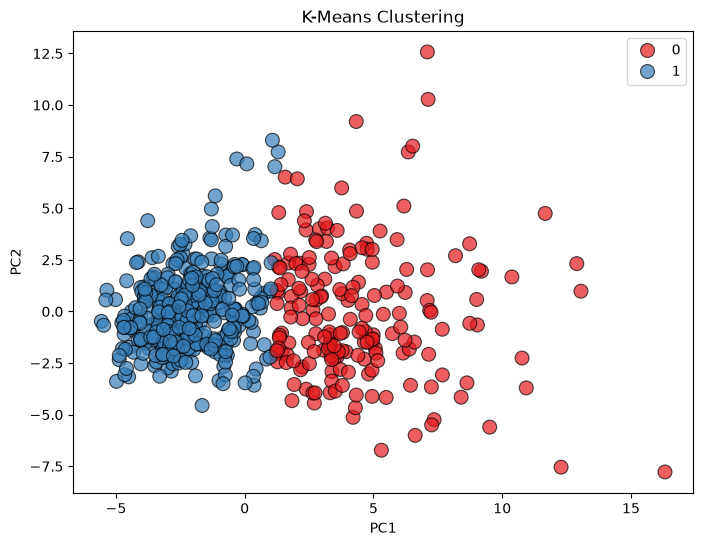

In [ ]:
plot_clusters(df, "K-Means Clustering")

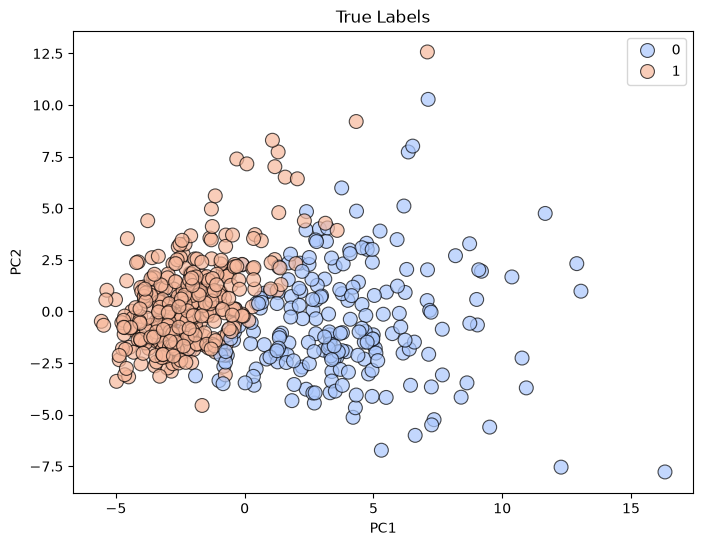

In [ ]:
plot_clusters(df, "True Labels", "True Label", "coolwarm")

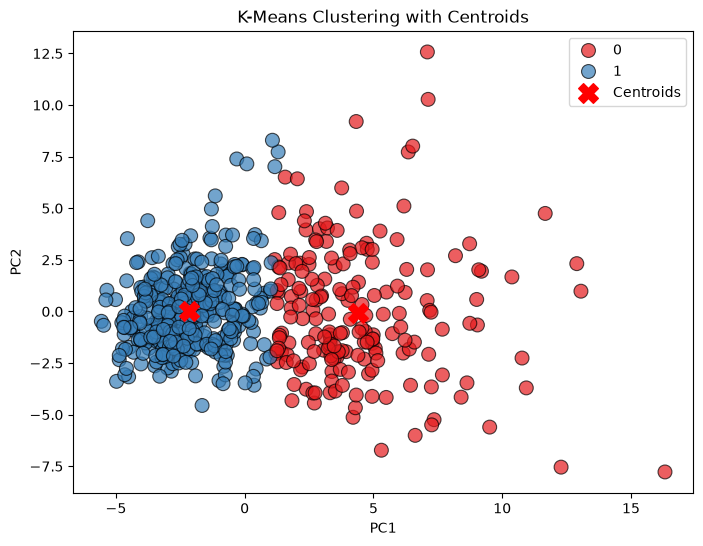

In [ ]:
plot_clusters(df, "K-Means Clustering with Centroids", centers=X_center)